In [2]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import operator
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

pd.options.mode.chained_assignment = None
import scipy.stats as stats
from  scipy.stats import chi2_contingency,chisquare
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.sandbox.stats.multicomp import multipletests

from util.api import calculate_bottom_dict
from util.api import create_lts_obj, compute_monad_usage_by_df, calculate_bottom, get_lts_list, make_columns_monad, compute_monad_transformer_usage_by_df

%matplotlib inline
plt.style.use('classic')

# Este notebook posee todos los análisis estadísticos realizados al conjunto de paquetes estudiado

## Principalmente se realizo Test de Anova y de Tukey al conjunto de datos

In [3]:
lts_list = get_lts_list()
df_list = []
df_by_category_list = []

for idx, lts in enumerate(lts_list):
    df = pd.read_pickle(f'../../data/dfs/lts-{lts}/lts-{lts}.df')
    df_list.append(df)
    
for idx, lts in enumerate(lts_list):
    df = pd.read_pickle(f'../../data/dfs/lts-{lts}/lts-{lts}-by-category.df')
    df_by_category_list.append(df)
    
for idx,df in enumerate(df_list):
    df_list[idx] = make_columns_monad(df,"transformer")
    df_list[idx] = make_columns_monad(df,"other_modules")

# El valor p es para determinar si puede o no puede rechazar la hipótesis nula, que dice que no existe ninguna asociación entre dos variables categóricas.

Valor p ≤ α: Las variables tienen una asociación estadísticamente significativa (Rechazar H0)
Si el valor p es menor que o igual al nivel de significancia, usted rechaza la hipótesis nula y concluye que hay una asociación estadísticamente significativa entre las variables.

Valor p > α: No se puede concluir que las variables están asociadas (No se puede rechazar H0)
Si el valor p es mayor que el nivel de significancia, usted no puede rechazar la hipótesis nula, porque no hay suficiente evidencia para concluir que las variables están asociadas.

## Cada valor categorico es comparado con el total de paquetes presentes en cada una de las versiones LTS

## Calcular el valor de PValue para las categorias de Stackage

In [5]:
categories = ['data', 'web', 'control', 'text', 'network']
data = {
    'data': [],
    'web': [],
    'control': [],
    'text': [],
    'network': []
}
count_pkgs = {
    'data': [],
    'web': [],
    'control': [],
    'text': [],
    'network': []
}
df_by_cat = []


for idx, df in enumerate(df_by_category_list):
    aux_df = df[['package', 'category']]
    aux_df = aux_df.groupby(['category']).count().reset_index().rename(columns={"package": "count"})
    aux_df.loc[:, 'version'] = lts_list[idx]
    df_by_cat.append(aux_df.sort_values(by=['count'], ascending=False))
    
for category in categories:
    for idx, lts in enumerate(lts_list):
        total_pkgs = len(df_by_category_list[idx])
        aux = int(df_by_cat[idx][df_by_cat[idx]['category'] == category]['count'].iloc[0]) * 100 / total_pkgs   

        count = int(df_by_cat[idx][df_by_cat[idx]['category'] == category]['count'].iloc[0])
        count_pkgs[category].append(count)
        data[category].append(aux)

others = []
per_others = []
for idx, lts in enumerate(lts_list):
    count = 0
    for category in count_pkgs:
        count += count_pkgs[category][idx]
    
    others.append(len(df_by_category_list[idx]) - count)
    per_others.append((len(df_by_category_list[idx]) - count) * 100 / len(df_by_category_list[idx]))

data['others'] = per_others
count_pkgs['others'] = others

# Test de anova

In [6]:
data = count_pkgs['data']
web = count_pkgs['web']
control = count_pkgs['control']
text = count_pkgs['text']
network = count_pkgs['network']


In [7]:
count_pkg = data + web + control + text + network
cat_list = [cat for idx,cat in enumerate(categories) for jdx,lts in enumerate(lts_list)]
dict_pkg = {'categories': cat_list, 'count_pkgs': count_pkg}

df_categories = pd.DataFrame(dict_pkg)

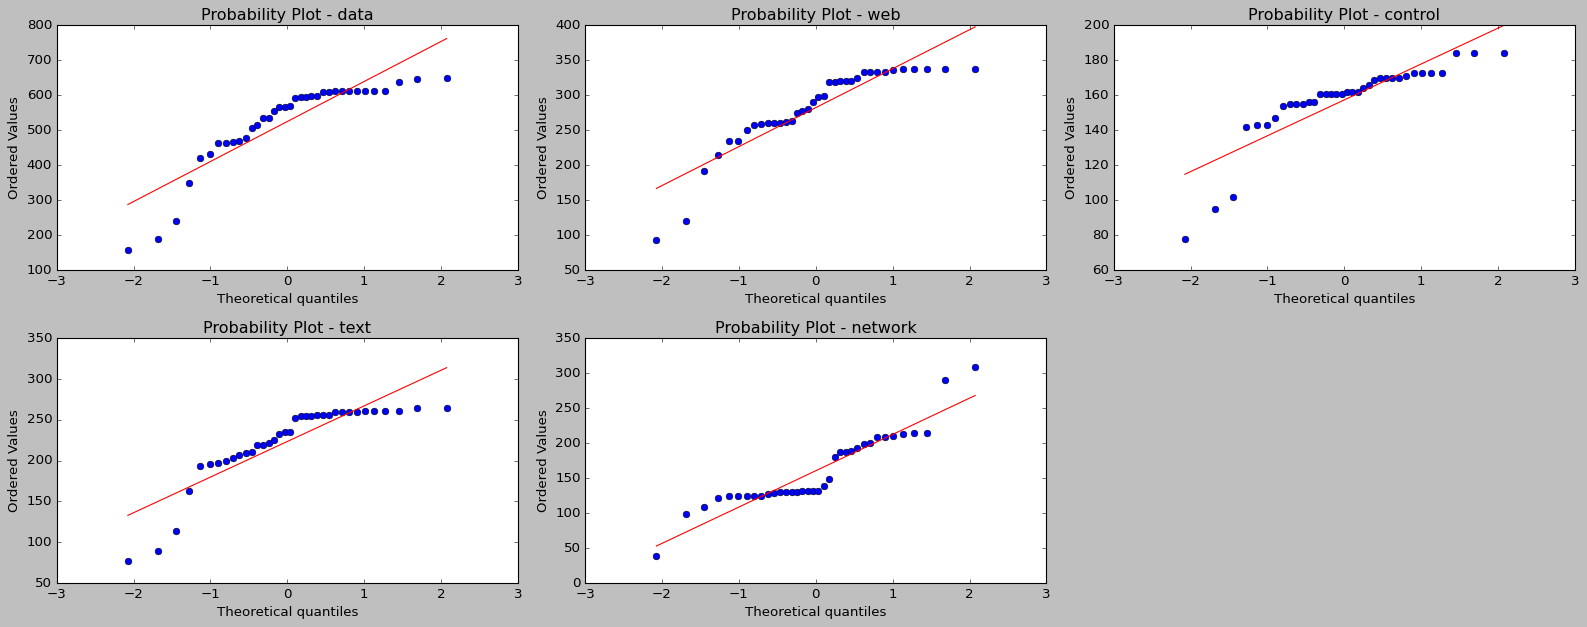

In [8]:
fig = plt.figure(figsize=(20,8))
unique_categories = df_categories['categories'].unique()

for idx,cat in enumerate(unique_categories):
    plt.subplot(2,3,idx+1)
    stats.probplot(df_categories[df_categories['categories'] == cat]['count_pkgs'], dist="norm", plot=plt)
    fig.tight_layout()
    plt.title("Probability Plot - " +  cat)
plt.show()

In [9]:
mod = ols('count_pkgs ~ categories',data=df_categories).fit()
aov_table= sm.stats.anova_lm(mod,typ=1)
print(aov_table)

               df        sum_sq        mean_sq           F        PR(>F)
categories    4.0  3.313622e+06  828405.575000  168.708741  6.268004e-59
Residual    175.0  8.592974e+05    4910.270635         NaN           NaN


In [10]:
f_val,p_val = stats.f_oneway(data,web,control,text,network)
print(p_val)

6.2680035038524925e-59


group1,group2,meandiff,p-adj,lower,upper,reject
control,data,367.6389,0.0,322.1125,413.1653,True
control,network,3.0833,0.9997,-42.4431,48.6097,False
control,text,65.9722,0.0009,20.4458,111.4986,True
control,web,125.0,0.0,79.4736,170.5264,True
data,network,-364.5556,0.0,-410.0819,-319.0292,True
data,text,-301.6667,0.0,-347.1931,-256.1403,True
data,web,-242.6389,0.0,-288.1653,-197.1125,True
network,text,62.8889,0.0018,17.3625,108.4153,True
network,web,121.9167,0.0,76.3903,167.4431,True
text,web,59.0278,0.0041,13.5014,104.5542,True


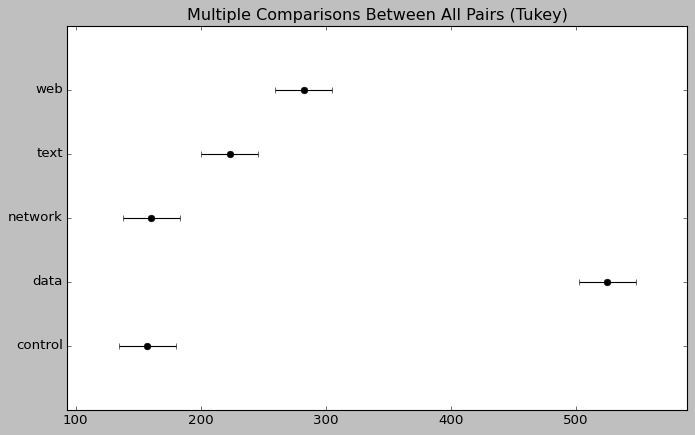

In [11]:
tukey = pairwise_tukeyhsd(endog=df_categories['count_pkgs'],
                         groups=df_categories['categories'],
                         alpha=0.05)
tukey.plot_simultaneous()

tukey.summary()

In [12]:
pvalue_list = []

for category in count_pkgs.keys():
    list_test_chi = []
    list_lts_len_cat = [len(df)-count_pkgs[category][idx] for idx,df in enumerate(df_by_category_list)]
    
    list_test_chi.append(count_pkgs[category])
    list_test_chi.append(list_lts_len_cat)
    
    chisq_statistic,pvalue,dof,expected_frep = chi2_contingency(list_test_chi)
    pvalue_list.append(pvalue)
    
    print(category,' have a pvalue of: ',pvalue)

data  have a pvalue of:  0.00020355526388927131
web  have a pvalue of:  7.966597956084807e-10
control  have a pvalue of:  7.436253965491458e-05
text  have a pvalue of:  0.9911502908814296
network  have a pvalue of:  3.159680058454946e-155
others  have a pvalue of:  2.5482500437494863e-23


## Pvalue categorias con mónadas

In [14]:
categories = ['data', 'web', 'control', 'text', 'network']
data = {
    'data': [],
    'web': [],
    'control': [],
    'text': [],
    'network': []
}
count_pkgs_mon = {
    'data': [],
    'web': [],
    'control': [],
    'text': [],
    'network': []
}
df_by_cat = []
for idx, df in enumerate(df_by_category_list):
    aux_df = df[['package', 'category', 'mtl-direct']]
    aux_df = aux_df[aux_df['mtl-direct'] == 1].groupby(['category']).count().reset_index().rename(columns={"package": "count"})   
    aux_df.loc[:, 'version'] = lts_list[idx]
    df_by_cat.append(aux_df.sort_values(by=['count'], ascending=False))

for category in categories:
    for idx, df in enumerate(df_by_category_list):
        total_pkgs = len(df_by_category_list[idx])
        aux = int(df_by_cat[idx][df_by_cat[idx]['category'] == category]['count'].iloc[0]) * 100 / total_pkgs   

        count = int(df_by_cat[idx][df_by_cat[idx]['category'] == category]['count'].iloc[0]) 
        count_pkgs_mon[category].append(count)
        data[category].append(aux)
others = []
per_others = []
for idx, lts in enumerate(lts_list):
    count = 0
    for category in count_pkgs_mon:
        count += count_pkgs_mon[category][idx]
    
    others.append(len(df_by_category_list[idx]) - count)
    per_others.append((len(df_by_category_list[idx]) - count) * 100 / len(df_by_category_list[idx]))

data['others'] = per_others
count_pkgs_mon['others'] = others

# Test de anova

In [15]:
data = count_pkgs_mon['data']
web = count_pkgs_mon['web']
control = count_pkgs_mon['control']
text = count_pkgs_mon['text']
network = count_pkgs_mon['network']

In [16]:
count_pkg = data + web + control + text + network
cat_list = [cat for idx,cat in enumerate(categories) for jdx,lts in enumerate(lts_list)]
dict_pkg = {'categories': cat_list, 'count_pkgs': count_pkg}

df_categories = pd.DataFrame(dict_pkg)

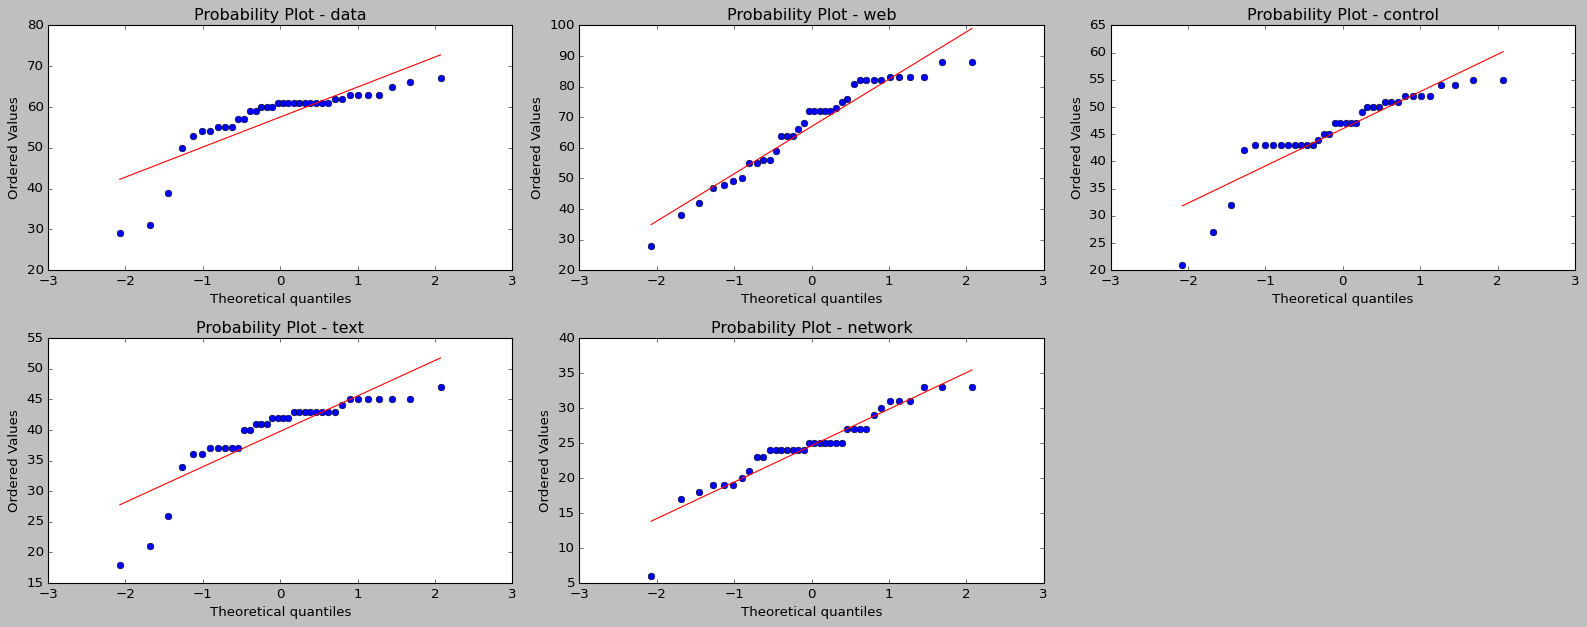

In [17]:
fig = plt.figure(figsize=(20,8))
unique_categories = df_categories['categories'].unique()

for idx,cat in enumerate(unique_categories):
    plt.subplot(2,3,idx+1)
    stats.probplot(df_categories[df_categories['categories'] == cat]['count_pkgs'], dist="norm", plot=plt)
    fig.tight_layout()
    plt.title("Probability Plot - " +  cat)
plt.show()

In [18]:
stats.f_oneway(data,web,control,text,network,others)

F_onewayResult(statistic=np.float64(726.9338070451706), pvalue=np.float64(2.006565104707931e-130))

group1,group2,meandiff,p-adj,lower,upper,reject
control,data,11.5278,0.0,5.4929,17.5627,True
control,network,-21.3611,0.0,-27.396,-15.3262,True
control,text,-6.2222,0.0397,-12.2571,-0.1873,True
control,web,20.9444,0.0,14.9095,26.9794,True
data,network,-32.8889,0.0,-38.9238,-26.854,True
data,text,-17.75,0.0,-23.7849,-11.7151,True
data,web,9.4167,0.0003,3.3818,15.4516,True
network,text,15.1389,0.0,9.104,21.1738,True
network,web,42.3056,0.0,36.2706,48.3405,True
text,web,27.1667,0.0,21.1318,33.2016,True


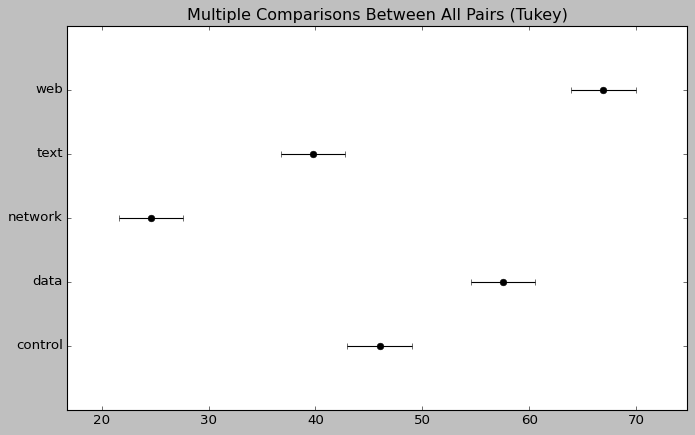

In [19]:
tukey = pairwise_tukeyhsd(endog=df_categories['count_pkgs'],
                         groups=df_categories['categories'],
                         alpha=0.05)
tukey.plot_simultaneous()

tukey.summary()

In [20]:
pvalue_list = []
len_lts = [len(df) for idx,df in enumerate(df_by_category_list)]

for category in count_pkgs_mon.keys():
    if category != 'others':
        list_test_chi = []
        list_lts_len_cat = [count_pkgs[category][idx]-count_pkgs_mon[category][idx] for idx,df in enumerate(df_by_category_list)]

        list_test_chi.append(count_pkgs_mon[category])
        list_test_chi.append(list_lts_len_cat)


        chisq_statistic,pvalue,dof,expected_frep = chi2_contingency(list_test_chi)
        pvalue_list.append(pvalue)
        print(category,' have a pvalue of: ',pvalue)

data  have a pvalue of:  0.07317942281061876
web  have a pvalue of:  0.521967920503441
control  have a pvalue of:  0.9999999904101499
text  have a pvalue of:  0.8498034404008243
network  have a pvalue of:  3.393980381471346e-05


## PValue para la estabilidad en Stackage

In [22]:
stabilities = ['', 'experimental', 'stable', 'provisional', 'alpha', 'beta']
data = {
    '': [],
    'experimental': [],
    'stable': [],
    'provisional': [],
    'alpha': [],
    'beta': []
}
count_pkgs = {
    '': [],
    'experimental': [],
    'stable': [],
    'provisional': [],
    'alpha': [],
    'beta': []
}
stability_df = []

df_stability_list = []
for idx, df in enumerate(df_list):
    list_pkg = []
    list_stab = []
    for idx,row in df.iterrows():
        pkg = row['package']
        stabs = row['stability']
        for stab in stabs:
            list_pkg.append(pkg)
            list_stab.append(stab)
    dict_stab = {'package':list_pkg,'stability':list_stab}
    df_stab = pd.DataFrame(dict_stab)
    df_stability_list.append(df_stab)
    
for idx, df in enumerate(df_stability_list):
    aux_df = df[['package', 'stability']]
    aux_df = aux_df.groupby(['stability']).count().reset_index().rename(columns={"package": "count"})
    aux_df.loc[:, 'version'] = lts_list[idx]
    stability_df.append(aux_df.sort_values(by=['count'], ascending=False))

for stability in stabilities:
    for idx, lts in enumerate(df_list):
        total_pkgs = len(df_list[idx])
        
        aux = int(stability_df[idx][stability_df[idx]['stability'] == stability]['count'].iloc[0]) * 100 / total_pkgs
        count = int(stability_df[idx][stability_df[idx]['stability'] == stability]['count'].iloc[0])
        count_pkgs[stability].append(count)
        data[stability].append(aux)

stabilities[0]='n/a'
for i in range (len(data['alpha'])):
    data['alpha'][i] = data['alpha'][i]+data['beta'][i]

In [23]:
experimental = count_pkgs['experimental']
stable = count_pkgs['stable']
provisional = count_pkgs['provisional']
alpha = count_pkgs['alpha']
beta = count_pkgs['beta']

In [24]:
count_pkg = experimental + stable + provisional + alpha + beta
stab_list = [stab for idx,stab in enumerate(stabilities[1:]) for jdx,lts in enumerate(lts_list)]
dict_pkg = {'stabilities': stab_list, 'count_pkgs': count_pkg}

df_stabilities = pd.DataFrame(dict_pkg)

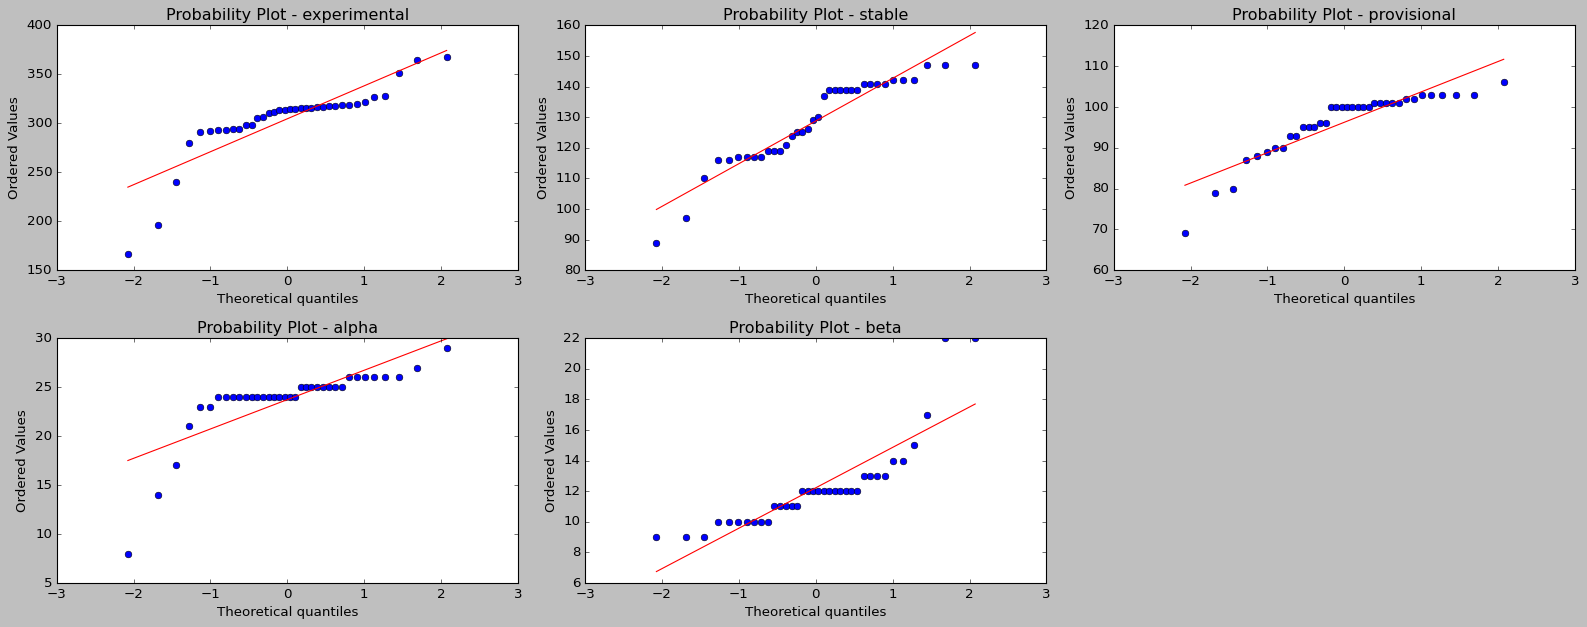

In [25]:
fig = plt.figure(figsize=(20,8))
unique_stabilities = df_stabilities['stabilities'].unique()

for idx,stab in enumerate(unique_stabilities):
    plt.subplot(2,3,idx+1)
    stats.probplot(df_stabilities[df_stabilities['stabilities'] == stab]['count_pkgs'], dist="norm", plot=plt)
    fig.tight_layout()
    plt.title("Probability Plot - " +  stab)
plt.show()

In [26]:
stats.f_oneway(experimental,stable,provisional,alpha,beta)

F_onewayResult(statistic=np.float64(1456.5423712808238), pvalue=np.float64(4.021856322476104e-133))

group1,group2,meandiff,p-adj,lower,upper,reject
alpha,beta,-11.5,0.0679,-23.5162,0.5162,False
alpha,experimental,280.8611,0.0,268.8449,292.8773,True
alpha,provisional,72.5278,0.0,60.5116,84.5439,True
alpha,stable,105.0278,0.0,93.0116,117.0439,True
beta,experimental,292.3611,0.0,280.3449,304.3773,True
beta,provisional,84.0278,0.0,72.0116,96.0439,True
beta,stable,116.5278,0.0,104.5116,128.5439,True
experimental,provisional,-208.3333,0.0,-220.3495,-196.3172,True
experimental,stable,-175.8333,0.0,-187.8495,-163.8172,True
provisional,stable,32.5,0.0,20.4838,44.5162,True


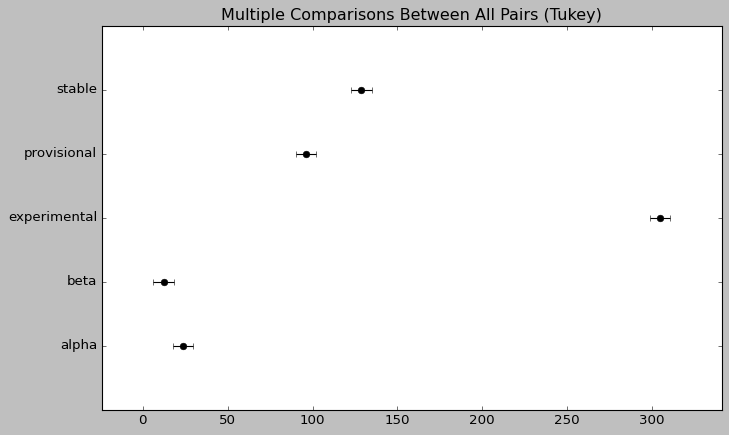

In [27]:
tukey = pairwise_tukeyhsd(endog=df_stabilities['count_pkgs'],
                         groups=df_stabilities['stabilities'],
                         alpha=0.05)
tukey.plot_simultaneous()

tukey.summary()

In [28]:
pvalue_list = []
len_lts = [len(df) for idx,df in enumerate(df_list)]

for stability in count_pkgs.keys():
    list_test_chi = []
    list_lts_len_sta = [len(df)-count_pkgs[stability][idx] for idx,df in enumerate(df_list)]
    
    list_test_chi.append(count_pkgs[stability])
    list_test_chi.append(list_lts_len_sta)
    
    
    chisq_statistic,pvalue,dof,expected_frep = chi2_contingency(list_test_chi)
    pvalue_list.append(pvalue)

    print(stability,' have a pvalue of: ',pvalue) if stability != '' else  print('N/A have a pvalue of: ',pvalue)

N/A have a pvalue of:  2.927757465442904e-197
experimental  have a pvalue of:  3.523455976618891e-74
stable  have a pvalue of:  1.1769406085929486e-27
provisional  have a pvalue of:  1.4314568913918106e-20
alpha  have a pvalue of:  0.9814401449690957
beta  have a pvalue of:  0.0006146417633958712


## PValue para estabilidad con mónadas

In [30]:
stabilities = ['', 'experimental', 'stable', 'provisional', 'alpha', 'beta']
data = {
    '': [],
    'experimental': [],
    'stable': [],
    'provisional': [],
    'alpha': [],
    'beta': []
}
count_pkgs_mon = {
    '': [],
    'experimental': [],
    'stable': [],
    'provisional': [],
    'alpha': [],
    'beta': []
}
stability_df = []

df_stability_list = []
for idx, df in enumerate(df_list):
    list_pkg = []
    list_stab = []
    list_mtl = []
    for idx,row in df.iterrows():
        pkg = row['package']
        stabs = row['stability']
        mtl = row['mtl-direct']
        for stab in stabs:
            list_pkg.append(pkg)
            list_stab.append(stab)
            list_mtl.append(mtl)
    dict_stab = {'package':list_pkg,'stability':list_stab,'mtl-direct':list_mtl}
    df_stab = pd.DataFrame(dict_stab)
    df_stability_list.append(df_stab)
    
for idx, df in enumerate(df_stability_list):
    aux_df = df[['package', 'stability', 'mtl-direct']]
    aux_df = aux_df[aux_df['mtl-direct'] == 1].groupby(['stability']).count().reset_index().rename(columns={"package": "count"})
    aux_df.loc[:, 'version'] = lts_list[idx]
    stability_df.append(aux_df.sort_values(by=['count'], ascending=False))

for stability in stabilities:
    for idx, lts in enumerate(df_list):
        total_pkgs = len(df_list[idx])
        
        aux = int(stability_df[idx][stability_df[idx]['stability'] == stability]['count'].iloc[0]) * 100 / total_pkgs
        count = int(stability_df[idx][stability_df[idx]['stability'] == stability]['count'].iloc[0])
        count_pkgs_mon[stability].append(count)
        data[stability].append(aux)
        
stabilities[0]='n/a'
for i in range (len(data['alpha'])):
    data['alpha'][i] = data['alpha'][i]+data['beta'][i]

In [31]:
suma = 0
for df in df_list:
    suma += len(df)
suma

96843

In [32]:
experimental = count_pkgs_mon['experimental']
stable = count_pkgs_mon['stable']
provisional = count_pkgs_mon['provisional']
alpha = count_pkgs_mon['alpha']
beta = count_pkgs_mon['beta']

In [33]:
count_pkg = experimental + stable + provisional + alpha + beta
stab_list = [stab for idx,stab in enumerate(stabilities[1:]) for jdx,lts in enumerate(lts_list)]
dict_pkg = {'stabilities': stab_list, 'count_pkgs': count_pkg}

df_stabilities = pd.DataFrame(dict_pkg)

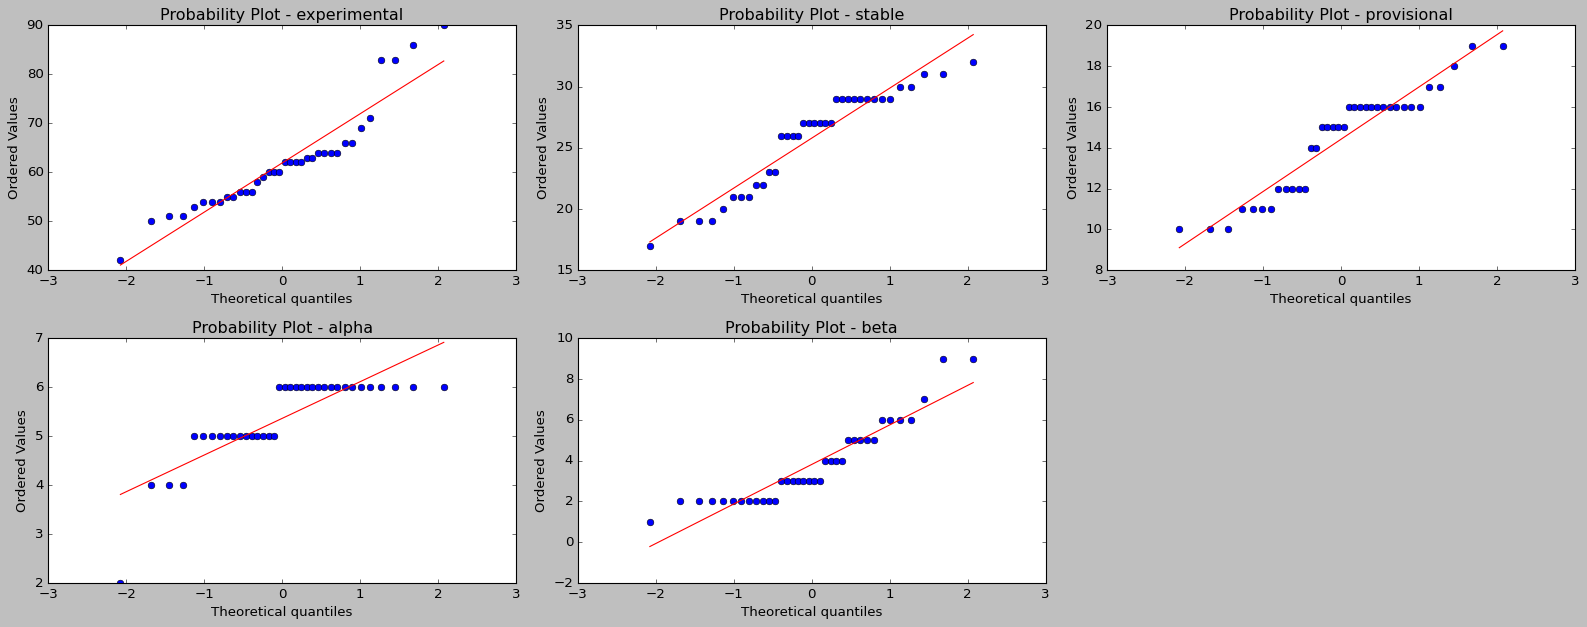

In [34]:
fig = plt.figure(figsize=(20,8))
unique_stabilities = df_stabilities['stabilities'].unique()

for idx,stab in enumerate(unique_stabilities):
    plt.subplot(2,3,idx+1)
    stats.probplot(df_stabilities[df_stabilities['stabilities'] == stab]['count_pkgs'], dist="norm", plot=plt)
    fig.tight_layout()
    plt.title("Probability Plot - " +  stab)
plt.show()

In [35]:
stats.f_oneway(experimental,stable,provisional,alpha,beta)

F_onewayResult(statistic=np.float64(758.1950522106334), pvalue=np.float64(2.4876491177338714e-109))

group1,group2,meandiff,p-adj,lower,upper,reject
alpha,beta,-1.5556,0.7092,-4.9284,1.8173,False
alpha,experimental,56.5278,0.0,53.1549,59.9007,True
alpha,provisional,9.0556,0.0,5.6827,12.4284,True
alpha,stable,20.4167,0.0,17.0438,23.7895,True
beta,experimental,58.0833,0.0,54.7105,61.4562,True
beta,provisional,10.6111,0.0,7.2382,13.984,True
beta,stable,21.9722,0.0,18.5993,25.3451,True
experimental,provisional,-47.4722,0.0,-50.8451,-44.0993,True
experimental,stable,-36.1111,0.0,-39.484,-32.7382,True
provisional,stable,11.3611,0.0,7.9882,14.734,True


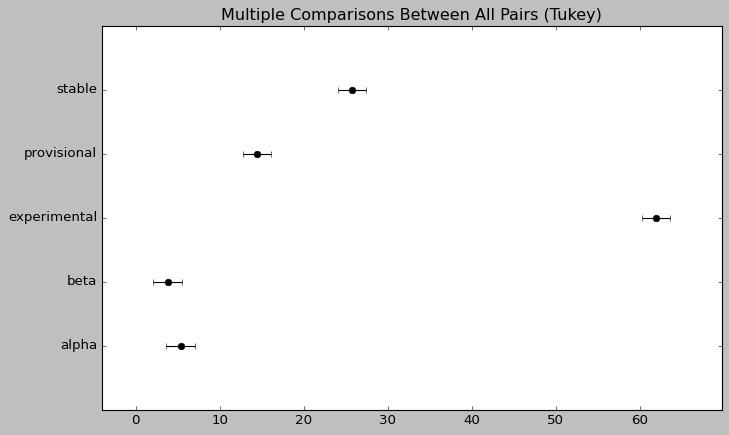

In [36]:
tukey = pairwise_tukeyhsd(endog=df_stabilities['count_pkgs'],
                         groups=df_stabilities['stabilities'],
                         alpha=0.05)
tukey.plot_simultaneous()

tukey.summary()

In [37]:
pvalue_list = []
len_lts = [len(df) for idx,df in enumerate(df_list)]

for stability in count_pkgs_mon.keys():
    list_test_chi = []
    list_lts_len_sta = [count_pkgs[stability][idx]-count_pkgs_mon[stability][idx] for idx,df in enumerate(df_list)]
    
    list_test_chi.append(count_pkgs_mon[stability])
    list_test_chi.append(list_lts_len_sta)
    
    chisq_statistic,pvalue,dof,expected_frep = chi2_contingency(list_test_chi)
    pvalue_list.append(pvalue)

    print(stability,' have a pvalue of: ',pvalue) if stability != '' else  print('N/A have a pvalue of: ',pvalue)

N/A have a pvalue of:  2.3237599029020725e-22
experimental  have a pvalue of:  0.04897395626754432
stable  have a pvalue of:  0.9999581465114545
provisional  have a pvalue of:  0.9995924099976176
alpha  have a pvalue of:  0.9999999999999999
beta  have a pvalue of:  0.4541902607480061


## Calcular PValue para los modulos de mtl en Stackage

In [38]:
monads_type = ['State', 'Reader', 'Trans', 'Writer', 'Error', 'Except', 'Identity', 'RWS', 'Continuation', 'List']
monads_type_df_list = []
data_monads = [[] for i in range(len(monads_type))]
for idx, df in enumerate(df_list):
    mtl_df = df[df['mtl-direct'] == 1]
    mtl_df = compute_monad_usage_by_df(mtl_df)
    monad_type_series = mtl_df[monads_type].sum().sort_values()
    monad_type_df = pd.DataFrame({ "type": monad_type_series.index, "count": monad_type_series.values })
    monads_type_df_list.append(monad_type_df)
    
for num, monad in enumerate(monads_type):    
    for idx, lts in enumerate(lts_list):
        aux = int(monads_type_df_list[idx][monads_type_df_list[idx]['type'] == monad]['count'].iloc[0])
        data_monads[num].append(aux)

In [39]:
State = data_monads[0]
Reader = data_monads[1]
Trans = data_monads[2]
Writer = data_monads[3]
Error = data_monads[4]
Except = data_monads[5]
Identity = data_monads[6]
RWS = data_monads[7]
Continuation = data_monads[8]
List = data_monads[9]

In [40]:
count_pkg = State + Reader + Trans + Writer + Error + Except + Identity + RWS + Continuation + List 
module_list = [module for idx,module in enumerate(monads_type) for jdx,lts in enumerate(lts_list)]
dict_pkg = {'modules': module_list, 'count_pkgs': count_pkg}

df_modules = pd.DataFrame(dict_pkg)

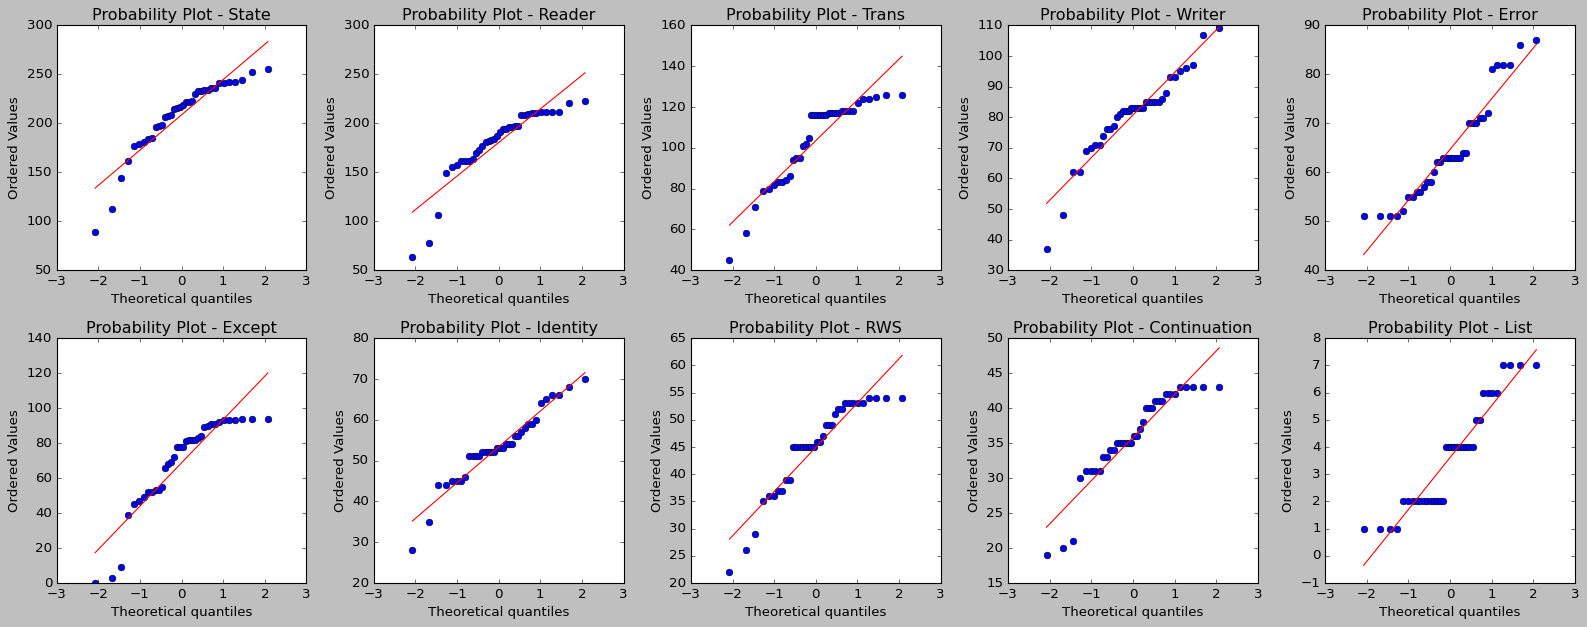

In [41]:
fig = plt.figure(figsize=(20,8))
unique_modules = df_modules['modules'].unique()

for idx,module in enumerate(unique_modules):
    plt.subplot(2,5,idx+1)
    stats.probplot(df_modules[df_modules['modules'] == module]['count_pkgs'], dist="norm", plot=plt)
    fig.tight_layout()
    plt.title("Probability Plot - " +  module)
plt.show()

In [42]:
stats.f_oneway(State,Reader,Trans,Writer,Error,Except,Identity,RWS,Continuation,List)

F_onewayResult(statistic=np.float64(341.4628932955521), pvalue=np.float64(2.1302770984868526e-167))

group1,group2,meandiff,p-adj,lower,upper,reject
Continuation,Error,28.8611,0.0,13.2205,44.5017,True
Continuation,Except,32.9167,0.0,17.2761,48.5573,True
Continuation,Identity,17.5556,0.0145,1.9149,33.1962,True
Continuation,List,-32.1944,0.0,-47.8351,-16.5538,True
Continuation,RWS,9.1389,0.6956,-6.5017,24.7795,False
Continuation,Reader,144.5833,0.0,128.9427,160.2239,True
Continuation,State,172.8333,0.0,157.1927,188.4739,True
Continuation,Trans,67.6944,0.0,52.0538,83.3351,True
Continuation,Writer,44.8611,0.0,29.2205,60.5017,True
Error,Except,4.0556,0.9982,-11.5851,19.6962,False


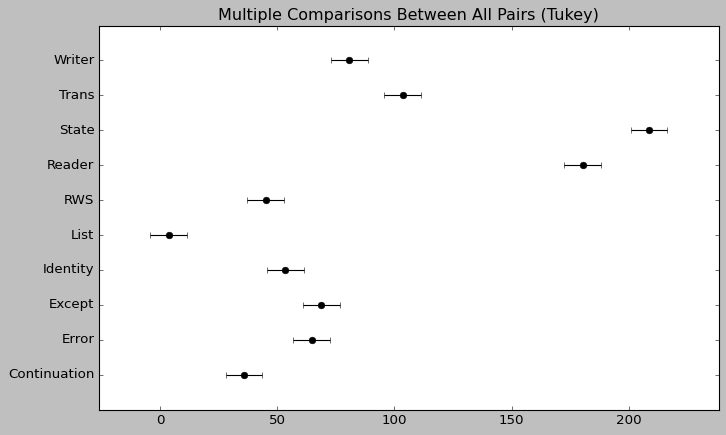

In [43]:
tukey = pairwise_tukeyhsd(endog=df_modules['count_pkgs'],
                         groups=df_modules['modules'],
                         alpha=0.05)
tukey.plot_simultaneous()

tukey.summary()

In [44]:
pvalue_list = []
list_lts_size_mon = []
for idy,lts in enumerate(data_monads[0]):
    size = 0
    for idx,monad_type in enumerate(data_monads):
        size += data_monads[idx][idy]
    list_lts_size_mon.append(size)

for idx,monad_type in enumerate(data_monads):
    list_test_chi = []
    list_lts_len_mon = [list_lts_size_mon[idx]-monad_type[idx] for idx,data in enumerate(list_lts_size_mon)]
    list_test_chi.append(monad_type)
    list_test_chi.append(list_lts_len_mon)
    
    chisq_statistic,pvalue,dof,expected_frep = chi2_contingency(list_test_chi)
    pvalue_list.append(pvalue)
    if idx != 9:
        print(monads_type[idx],' have a pvalue of: ',pvalue) if idx != 8  else print('Continuation and List have a pvalue of: ',pvalue) 

State  have a pvalue of:  0.999999999891044
Reader  have a pvalue of:  0.8496159276622091
Trans  have a pvalue of:  0.8407114468337201
Writer  have a pvalue of:  0.9865287659989692
Error  have a pvalue of:  1.5755738200775545e-12
Except  have a pvalue of:  1.2805076781140482e-26
Identity  have a pvalue of:  0.0724246637483089
RWS  have a pvalue of:  0.9999999998066488
Continuation and List have a pvalue of:  0.9999999999578802


## Calcular PValue para los modulos de transformer en Stackage

In [45]:
transformer_monads = ['State','Reader', 'Writer', 'Except', 'Identity', 'RWS', 'Class', 'Cont', 'Maybe']
monads_type_df_list = []
data_monads = [[] for i in range(len(transformer_monads))]
for idx, df in enumerate(df_list):
    df = df[df['transformer-direct'] == 1]
    df_trans = compute_monad_transformer_usage_by_df(df)
    monad_type_series = df_trans[transformer_monads].sum().sort_values()
    monad_type_df = pd.DataFrame({ "type": monad_type_series.index, "count": monad_type_series.values })
    monads_type_df_list.append(monad_type_df)
    
for num, monad in enumerate(transformer_monads):    
    for idx, lts in enumerate(lts_list):
        aux = int(monads_type_df_list[idx][monads_type_df_list[idx]['type'] == monad]['count'].iloc[0])
        data_monads[num].append(aux)

In [46]:
State = data_monads[0]
Reader = data_monads[1]
Writer = data_monads[2]
Except = data_monads[3]
Identity = data_monads[4]
RWS = data_monads[5]
Class = data_monads[6]
Cont = data_monads[7]
Maybe = data_monads[8]

In [47]:
count_pkg = State + Reader + Writer + Except + Identity + RWS + Class + Cont + Maybe
module_list = [module for idx,module in enumerate(transformer_monads) for jdx,lts in enumerate(lts_list)]
dict_pkg = {'modules': module_list, 'count_pkgs': count_pkg}

df_modules = pd.DataFrame(dict_pkg)

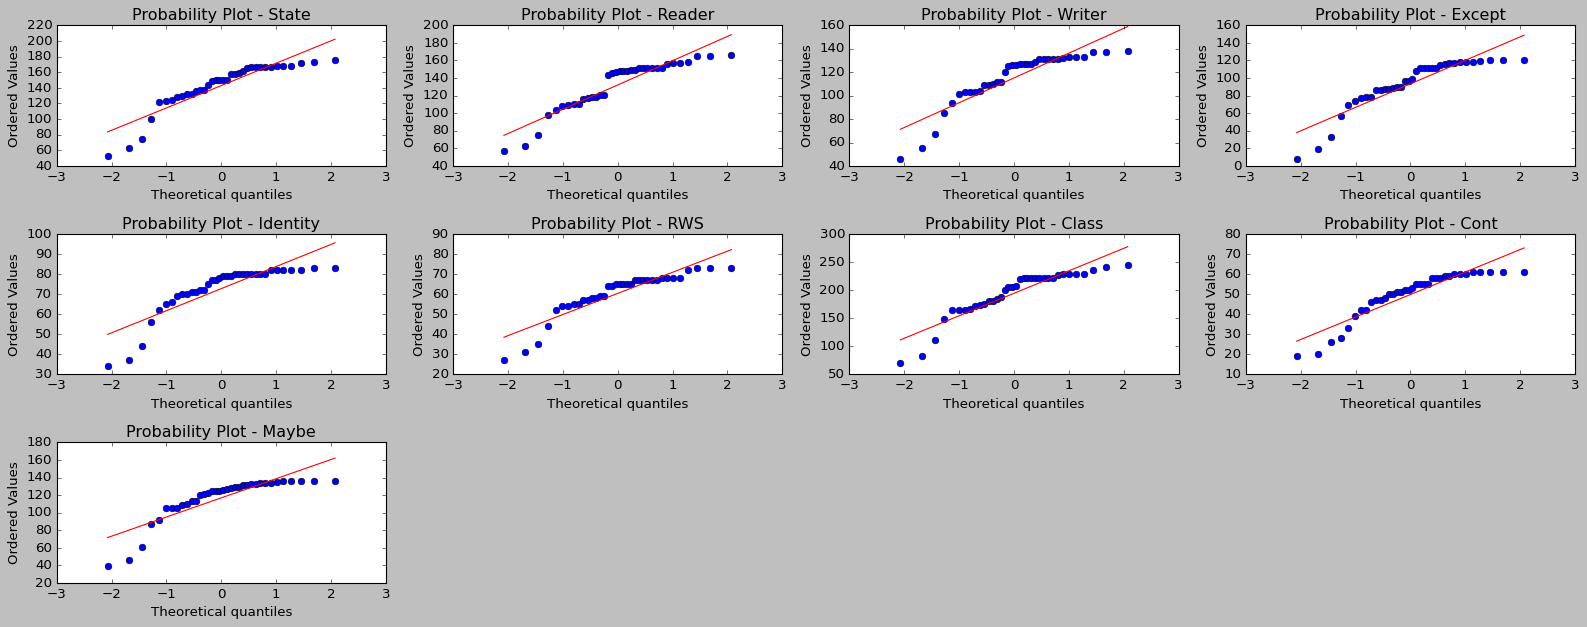

In [48]:
fig = plt.figure(figsize=(20,8))
unique_modules = df_modules['modules'].unique()

for idx,module in enumerate(unique_modules):
    plt.subplot(3,4,idx+1)
    stats.probplot(df_modules[df_modules['modules'] == module]['count_pkgs'], dist="norm", plot=plt)
    fig.tight_layout()
    plt.title("Probability Plot - " +  module)
plt.show()

In [49]:
stats.f_oneway(State,Reader,Writer, Except, Identity, RWS, Class, Cont, Maybe)

F_onewayResult(statistic=np.float64(114.31989848694231), pvalue=np.float64(1.975652692845705e-88))

group1,group2,meandiff,p-adj,lower,upper,reject
Class,Cont,-144.5833,0.0,-163.3476,-125.8191,True
Class,Except,-100.9722,0.0,-119.7365,-82.208,True
Class,Identity,-121.6389,0.0,-140.4032,-102.8746,True
Class,Maybe,-77.4722,0.0,-96.2365,-58.708,True
Class,RWS,-134.0278,0.0,-152.792,-115.2635,True
Class,Reader,-62.25,0.0,-81.0143,-43.4857,True
Class,State,-51.4722,0.0,-70.2365,-32.708,True
Class,Writer,-79.25,0.0,-98.0143,-60.4857,True
Cont,Except,43.6111,0.0,24.8468,62.3754,True
Cont,Identity,22.9444,0.005,4.1802,41.7087,True


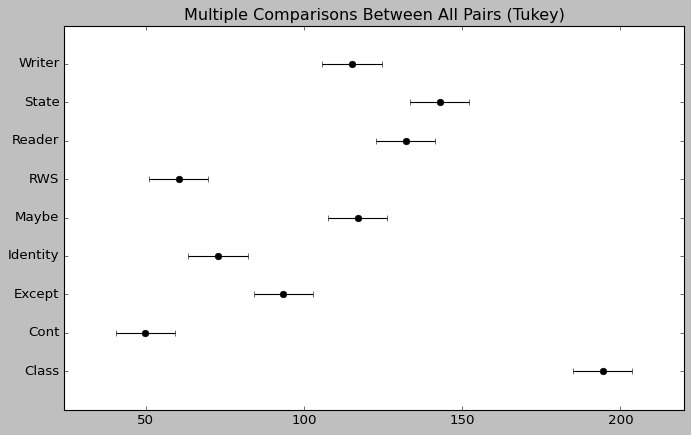

In [50]:
tukey = pairwise_tukeyhsd(endog=df_modules['count_pkgs'],
                         groups=df_modules['modules'],
                         alpha=0.05)
tukey.plot_simultaneous()

tukey.summary()